# 5-Supervised Learning :

In this notebook, we build supervised learning models to predict customer ratings from review text.
We first address the rating prediction task (1 to 5 stars) using several approaches, from classical machine learning models to neural and transformer based models.

We then compare these approaches and analyze their strengths and limitations before moving to sentiment classification in a second part.

##Part A: Rating prediction

The goal of this first supervised task is to predict the exact rating of a review, from 1 to 5 stars.

This is a challenging multi class classification problem because customer reviews often express nuanced opinions, especially for intermediate ratings.

We begin with classical machine learning models based on TF-IDF features, then move to more advanced approaches such as neural networks with embedding layers, pre trained embeddings, transformer based models, and LLM based prediction.

- Imports


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

Load the dataset

In [2]:
df = pd.read_csv("../data/processed/reviews_supervised.csv") # vs code
#df = pd.read_csv("reviews_supervised.csv") #on colab
df.shape

(24104, 14)

The dataset used for supervised learning "df_supervised" is derived from the cleaned dataset by removing all rows with missing ratings (`note`).
This step is necessary because supervised learning requires labeled data.

- Check

In [3]:
df.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,source_file,avis_clean,avis_clean_fr
0,5,claire-m-130353,"les prix au top, la facilité d'inscription et ...",Direct Assurance,auto,train,2021-08-31,2021-08-01,"top prices, ease of registration and clear ser...",NaN,NaN,avis_21_traduit.xlsx,les prix au top la facilité d inscription et l...,les prix au top la facilité d inscription et l...
1,2,tontonlouis-90075,je n'ai pas les moyens d'attendre 3 à 4 semain...,Cegema Assurances,sante,train,2020-05-30,2020-05-01,I cannot afford to wait 3 to 4 weeks for reimb...,NaN,NaN,avis_21_traduit.xlsx,je n ai pas les moyens d attendre 3 à 4 semain...,je n ai pas les moyens d attendre 3 à 4 semain...
2,1,fred78-132197,Je voulais assurer une Tesla Modèle 3 LR ...\n...,MACIF,auto,train,2021-09-10,2021-09-01,I wanted to ensure a Tesla Model 3 LR ...\nThe...,NaN,NaN,avis_21_traduit.xlsx,je voulais assurer une tesla modèle 3 lr le pr...,je voulais assurer une tesla modèle 3 lr le pr...
3,1,sud-70690,"Je suis en arrêt de travail depuis nov 2017 ,a...",Cardif,credit,train,2019-02-07,2019-02-01,"I am on work stoppage since Nov 2017, assured ...",NaN,NaN,avis_21_traduit.xlsx,je suis en arrêt de travail depuis nov 2017 as...,je suis en arrêt de travail depuis nov 2017 as...
4,1,fofi-80683,inadmissible... je leur ai réglé un trop perçu...,Harmonie Mutuelle,sante,train,2019-11-04,2019-11-01,Inadmissible ... I set them too perceived foll...,NaN,NaN,avis_21_traduit.xlsx,inadmissible je leur ai réglé un trop perçu su...,inadmissible je leur ai réglé un trop perçu su...


- Prepare the data

In [4]:
# features and target
X = df["avis_clean"]
y = df["note"]

- Test and split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #we use stratify to maintain class distribution in train and test sets

STOPWORDS

In [6]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [7]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/koralie/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
french_stopwords = set(stopwords.words("french"))

In [9]:
french_stopwords = french_stopwords - {"pas", "ne", "jamais"}

Before applying TF_IDF we will delete all the stopword who could reduce the explainabality

## 1) Classical models

- TF-IDF

##### Improved Text Representation

We refine the TF-IDF representation by:

- removing common french stopwords to reduce noise,
- removing rare words (min_df) that do not generalize well,
- removing very frequent words (max_df) that carry little information.
- change from 2gram to 3gram

This allows the model to focus on more meaningful and discriminative terms.

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1,3),stop_words=list(french_stopwords),min_df=5,max_df=0.9)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


TF-IDF stands for (Term Frequency - Inverse Document Frequency).
It is a method used to convert text into numerical features that can be used by machine learning models.

It works by assigning a weight to each word based on:
- how often the word appears in a document (Term frequency),
- how rare the word is across all documents (Inverse document frequency).

The main idea is to give higher importance to words that are frequent in a specific review but not common across all reviews.
This allows the model to focus on meaningful and discriminative words rather than very common words that carry little information.

- Models

### 1) Logistic Regression

We edited the code to fit the streamlit needs

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# we use a pipeline to combine TF-IDF vectorization and Logistic regression into a single object, which makes training, evaluation and deployment easier.

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=1000,ngram_range=(1,3),stop_words=list(french_stopwords)+ ["assurance", "assureur","assurances"] ,min_df=5,max_df=0.9)),
    ("clf", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred_lr = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_lr)
print(accuracy)
print(classification_report(y_test, y_pred_lr))

0.5189794648413192
              precision    recall  f1-score   support

           1       0.61      0.85      0.71      1454
           2       0.35      0.20      0.25       743
           3       0.31      0.18      0.23       677
           4       0.44      0.44      0.44       977
           5       0.56      0.59      0.57       970

    accuracy                           0.52      4821
   macro avg       0.46      0.45      0.44      4821
weighted avg       0.48      0.52      0.49      4821



- Confusion matrix

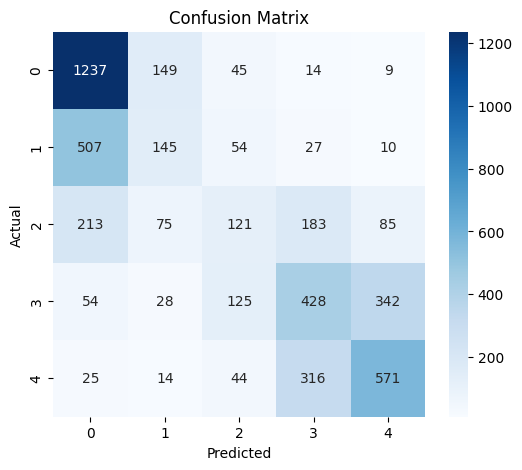

In [11]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

- Save the model for the app

In [12]:
import os
import joblib

path = os.path.abspath("../app/models/tfidf_lr.pkl")

joblib.dump(pipeline, path)

print("Saved at:", path)

Saved at: /Users/koralie/Desktop/nlp_project2/app/models/tfidf_lr.pkl


After trying the streamlit app, we removed domain specific words such as "assurance" because they were highly frequent and biased toward negative reviews, which could mislead the model. This helps improve generalization and reduces spurious correlations.

### 2) Naive Bayes

We test a multinomial naive bayes model which is well suited for text classification tasks based on word frequencies.
This model is simple, fast and often performs well as a baseline in NLP problems.

In [20]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)

y_pred_nb = model_nb.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.5158680771624145
              precision    recall  f1-score   support

           1       0.55      0.95      0.69      1454
           2       0.25      0.03      0.05       743
           3       0.33      0.11      0.16       677
           4       0.45      0.40      0.42       977
           5       0.55      0.64      0.59       970

    accuracy                           0.52      4821
   macro avg       0.43      0.43      0.39      4821
weighted avg       0.45      0.52      0.45      4821



### 3) LinearSVC

We test a Linear support vector machine (LinearSVC) which is known to perform very well on high dimensional sparse data such as TF-IDF representations.
This model aims to find the optimal boundary between classes in the feature space.

In [21]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC()
model_svm.fit(X_train_tfidf, y_train)

y_pred_svm = model_svm.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.5164903546981954
              precision    recall  f1-score   support

           1       0.61      0.85      0.71      1454
           2       0.34      0.19      0.24       743
           3       0.30      0.13      0.18       677
           4       0.44      0.42      0.43       977
           5       0.54      0.63      0.58       970

    accuracy                           0.52      4821
   macro avg       0.45      0.44      0.43      4821
weighted avg       0.48      0.52      0.48      4821



Although the performance remains moderate, it is clearly above random guessing(20 % because there is 5 classes). However the models still struggle with intermediate ratings which remain difficult to distinguish.

### 4) XGBOOST

In [22]:
%pip install xgboost

In [24]:
from xgboost import XGBClassifier

# XGBoost expects labels starting from 0
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

model_xgb = XGBClassifier(n_estimators=100,max_depth=6,learning_rate=0.1,objective="multi:softmax",num_class=5,eval_metric="mlogloss",use_label_encoder=False)

model_xgb.fit(X_train_tfidf, y_train_xgb)

y_pred_xgb = model_xgb.predict(X_test_tfidf)

# Convert predictions back to the original 1–5 scale
y_pred_xgb = y_pred_xgb + 1

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:50:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.5086081725783033
              precision    recall  f1-score   support

           1       0.55      0.92      0.69      1454
           2       0.37      0.06      0.11       743
           3       0.37      0.08      0.14       677
           4       0.42      0.46      0.44       977
           5       0.55      0.57      0.56       970

    accuracy                           0.51      4821
   macro avg       0.45      0.42      0.39      4821
weighted avg       0.47      0.51      0.44      4821



- Comparison of classical models

In [26]:
results_rating_classical = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "LinearSVC", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr),accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm),accuracy_score(y_test, y_pred_xgb)]})

results_rating_classical.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.518772
2,LinearSVC,0.516490
1,Naive Bayes,0.515868
3,XGBoost,0.508608


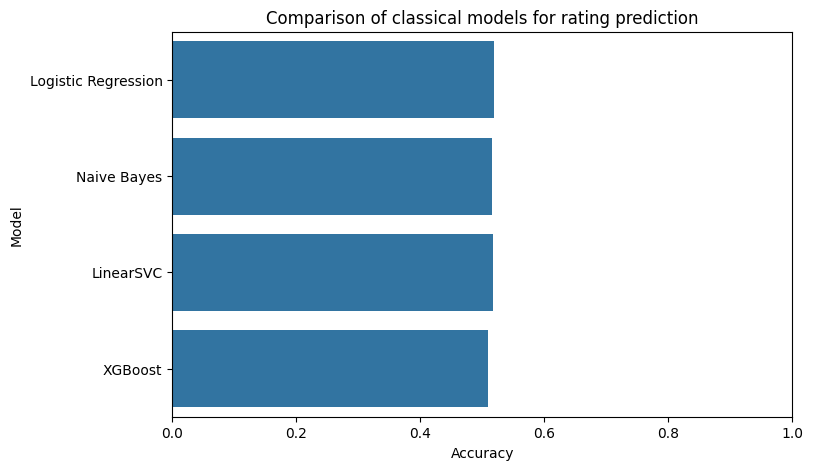

In [27]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_rating_classical, x="Accuracy", y="Model")
plt.title("Comparison of classical models for rating prediction")
plt.xlim(0, 1)
plt.show()

The classical models achieve similar performance overall.  
Although the results remain clearly above random guessing, intermediate ratings are still difficult to distinguish, which suggests that exact rating prediction is a challenging task.

## 2) Basic neural model with an embedding layer

In [28]:
%pip install tensorflow

In [29]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense
from tensorflow.keras.utils import to_categorical

- Tokenization and padding

In [30]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

- Labels for neural network

In [31]:
# neural networks prefer labels starting at 0
y_train_nn = y_train - 1
y_test_nn = y_test - 1

y_train_cat = to_categorical(y_train_nn, num_classes=5)
y_test_cat = to_categorical(y_test_nn, num_classes=5)

- model definition

In [32]:
embedding_model = Sequential([Embedding(input_dim=10000, output_dim=64, input_length=max_len),GlobalAveragePooling1D(),
    Dense(64, activation="relu"),Dense(5, activation="softmax")])

embedding_model.compile(loss="categorical_crossentropy",optimizer="adam",metrics=["accuracy"])

embedding_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

- Training

In [33]:
history = embedding_model.fit(X_train_pad,y_train_cat,validation_split=0.2,
    epochs=5,batch_size=32)

Epoch 1/5
483/483 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.4437 - loss: 1.3045 - val_accuracy: 0.4825 - val_loss: 1.1682
Epoch 2/5
483/483 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.5017 - loss: 1.1113 - val_accuracy: 0.4830 - val_loss: 1.1239
Epoch 3/5
483/483 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5180 - loss: 1.0590 - val_accuracy: 0.4778 - val_loss: 1.1802
Epoch 4/5
483/483 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.5435 - loss: 1.0142 - val_accuracy: 0.5170 - val_loss: 1.0869
Epoch 5/5
483/483 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5725 - loss: 0.9545 - val_accuracy: 0.5219 - val_loss: 1.0996


- Evaluation

In [34]:
loss, acc = embedding_model.evaluate(X_test_pad, y_test_cat)
print("Test accuracy:", acc)

151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5264 - loss: 1.0815
Test accuracy: 0.5264468193054199


- Predictions

In [35]:
y_pred_embedding = embedding_model.predict(X_test_pad)
y_pred_embedding = np.argmax(y_pred_embedding, axis=1) + 1

151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [36]:
print(classification_report(y_test, y_pred_embedding))

              precision    recall  f1-score   support

           1       0.61      0.86      0.71      1454
           2       0.36      0.16      0.22       743
           3       0.31      0.23      0.26       677
           4       0.47      0.43      0.45       977
           5       0.58      0.62      0.60       970

    accuracy                           0.53      4821
   macro avg       0.46      0.46      0.45      4821
weighted avg       0.49      0.53      0.50      4821



## 3) Model with pre trained embedding

In this section, we use pre trained word embeddings to represent the reviews.
Unlike embeddings learned from scratch, pre trained embeddings capture semantic relationships learned from large external corpora.
We represent each review by averaging the embeddings of its words and use these representations for classification.

- Installation

In [39]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 24.1 MB/s eta 0:00:00


- Imports and model loading

In [40]:
import gensim.downloader as api
import numpy as np

# load pre trained Glove embeddings (100 dimensions)
w2v_model = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


- Sentence vectorization function

In [42]:
def sentence_to_vector(text):
    words = str(text).split()
    vectors = []

    for w in words:
        if w in w2v_model:
            vectors.append(w2v_model[w])

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

- Transform the dataset

In [43]:
X_train_emb = np.array([sentence_to_vector(t) for t in X_train])
X_test_emb = np.array([sentence_to_vector(t) for t in X_test])

- Model training

In [44]:
from sklearn.linear_model import LogisticRegression

model_emb = LogisticRegression(max_iter=1000)
model_emb.fit(X_train_emb, y_train)

LogisticRegression(max_iter=1000)

- Model evaluation

In [45]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_emb = model_emb.predict(X_test_emb)

print("Accuracy:", accuracy_score(y_test, y_pred_emb))
print(classification_report(y_test, y_pred_emb))

Accuracy: 0.4642190416925949
              precision    recall  f1-score   support

           1       0.49      0.90      0.64      1454
           2       0.15      0.01      0.02       743
           3       0.28      0.06      0.10       677
           4       0.38      0.36      0.37       977
           5       0.51      0.54      0.53       970

    accuracy                           0.46      4821
   macro avg       0.36      0.38      0.33      4821
weighted avg       0.39      0.46      0.39      4821



## 4) Sentence embeddingd model (SBERT/ equivalent)

Instead of representing each review with word counts, we can encode each review into a dense sentence embedding and train a classifier on top of these representations.

In [46]:
%pip install sentence-transformers

In [47]:
from sentence_transformers import SentenceTransformer

In [48]:
sbert_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

X_train_sbert = sbert_model.encode(X_train.tolist(), show_progress_bar=True)
X_test_sbert = sbert_model.encode(X_test.tolist(), show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/603 [00:00<?, ?it/s]

Batches:   0%|          | 0/151 [00:00<?, ?it/s]

- Classifier on top of sentence embeddings

In [49]:
model_sbert = LogisticRegression(max_iter=1000)
model_sbert.fit(X_train_sbert, y_train)

y_pred_sbert = model_sbert.predict(X_test_sbert)

In [50]:
print("Accuracy:", accuracy_score(y_test, y_pred_sbert))
print(classification_report(y_test, y_pred_sbert))

Accuracy: 0.5239576851275669
              precision    recall  f1-score   support

           1       0.60      0.89      0.72      1454
           2       0.34      0.13      0.19       743
           3       0.30      0.16      0.21       677
           4       0.45      0.43      0.44       977
           5       0.56      0.62      0.59       970

    accuracy                           0.52      4821
   macro avg       0.45      0.45      0.43      4821
weighted avg       0.48      0.52      0.48      4821



## 5) Transformer based model (BERT/ Hugging Face)

We now test a transformer based model from Hugging Face.
Unlike TF-IDF, transformer models capture the meaning of words depending on their context, which may improve performance on nuanced reviews.

In [51]:
%pip install transformers datasets torch

First exploration with a pre trained model

In [52]:
from transformers import pipeline

classifier_bert = pipeline("text-classification",model="nlptown/bert-base-multilingual-uncased-sentiment")

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [53]:
sample_reviews = X_test.iloc[:50].tolist()
bert_preds = classifier_bert(sample_reviews)
bert_preds[:5]

[{'label': '4 stars', 'score': 0.46167001128196716},
 {'label': '3 stars', 'score': 0.41538330912590027},
 {'label': '1 star', 'score': 0.6042366027832031},
 {'label': '5 stars', 'score': 0.737351655960083},
 {'label': '5 stars', 'score': 0.5011894106864929}]

Convert predictions

In [54]:
def extract_star_label(pred):
    # labels look like "1 star", "2 stars" ...
    return int(pred["label"][0])

y_true_bert = y_test.iloc[:50].tolist()
y_pred_bert = [extract_star_label(p) for p in bert_preds]

In [55]:
print("Accuracy:", accuracy_score(y_true_bert, y_pred_bert))
print(classification_report(y_true_bert, y_pred_bert))

Accuracy: 0.54
              precision    recall  f1-score   support

           1       0.47      0.90      0.62        10
           2       0.00      0.00      0.00         8
           3       0.50      0.12      0.20         8
           4       0.50      0.55      0.52        11
           5       0.73      0.85      0.79        13

    accuracy                           0.54        50
   macro avg       0.44      0.48      0.43        50
weighted avg       0.48      0.54      0.48        50



This first experiment does not fine-tune BERT on our dataset, but it still provides a useful transformer-based baseline for comparison.

## 6) LLM based rating prediction

In this section, we use a LLM to predict the rating directly from the review text.
This approach does not rely on traditional feature engineering such as TF-IDF or embeddings. Instead, it leverages the reasoning capabilities of a pretrained language model.
We test both zero shot and few shot prompting strategies and compare the results with previous models.

Example prompt structure

In [56]:
def build_rating_prompt(review):
    return f"""
You are an expert in customer review analysis.

Your task is to predict the rating of the following insurance review on a scale from 1 to 5 stars.

Return only one integer between 1 and 5.

Review:
{review}
"""

- LLM Inferance (hugging Face)

In [60]:
from transformers import pipeline

llm = pipeline("text-generation", model="google/flan-t5-base")

def predict_rating_llm(review):
    prompt = build_rating_prompt(review)
    result = llm(prompt, max_length=100)

    output = result[0]["generated_text"]

    # Extract number
    for i in ["1","2","3","4","5"]:
        if i in output:
            return int(i)

    return None

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLl

- Example predictions

In [61]:
sample_reviews = X_test[:10].tolist()

for review in sample_reviews:
    pred = predict_rating_llm(review)
    print("Review:", review[:100])
    print("Predicted rating:", pred)
    print("-"*50)

Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Review: simple et rapide d utilisation pour l instant à voire pour le service client plus tard demander 150 
Predicted rating: 1
--------------------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Review: pas évident de souscrire par internet quand on n y connais pas grand chose mais pour mon assurance m
Predicted rating: 1
--------------------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Review: l attente téléphonique est peu importante pour prise en compte de nos appels par un conseiller les c
Predicted rating: 1
--------------------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Review: j ai voulu assuré un véhicule de sport la réponse de la macif après étude de la faisabilité je suis 
Predicted rating: 1
--------------------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Review: cette assurance est à éviter je ne suis pas du genre difficile je n ai que rarement des sinistres 1 
Predicted rating: 1
--------------------------------------------------


- Evaluation on a subset

In [62]:
from sklearn.metrics import accuracy_score

# take small subset (LLM = slow)
subset_X = X_test[:50]
subset_y = y_test[:50]

y_pred_llm = []

for review in subset_X:
    pred = predict_rating_llm(review)
    y_pred_llm.append(pred if pred is not None else 3)

print("Accuracy:", accuracy_score(subset_y, y_pred_llm))

Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Accuracy: 0.2


## Few-shot prompting

In [59]:
def build_few_shot_prompt(review):
    return f"""
You are an expert in customer review analysis.

Here are some examples:

Review: "Service client catastrophique, aucun remboursement."
Rating: 1

Review: "Très satisfait, remboursement rapide et efficace."
Rating: 5

Review: "Correct mais quelques délais."
Rating: 3

Now predict the rating for the following review (1 to 5):

Review:
{review}

Return only one integer.
"""

## 7) Final comparison for rating prediction

We now summarize the performance of the different approaches tested for exact rating prediction.

In [66]:
results_rating_all = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "LinearSVC",
        "XGBoost",
        "Embedding Layer Model","Pre trained embeddings",
        "SBERT + Logistic Regression",
        "Pre-trained BERT (subset)", "LLM"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_embedding),
        accuracy_score(y_test, y_pred_emb),
        accuracy_score(y_test, y_pred_sbert),
        accuracy_score(y_true_bert, y_pred_bert),
        accuracy_score(subset_y, y_pred_llm)
    ]
})

results_rating_all.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
7,Pre-trained BERT (subset),0.540000
4,Embedding Layer Model,0.526447
6,SBERT + Logistic Regression,0.523958
0,Logistic Regression,0.518772
2,LinearSVC,0.516490
1,Naive Bayes,0.515868
3,XGBoost,0.508608
5,Pre trained embeddings,0.464219
8,LLM,0.200000


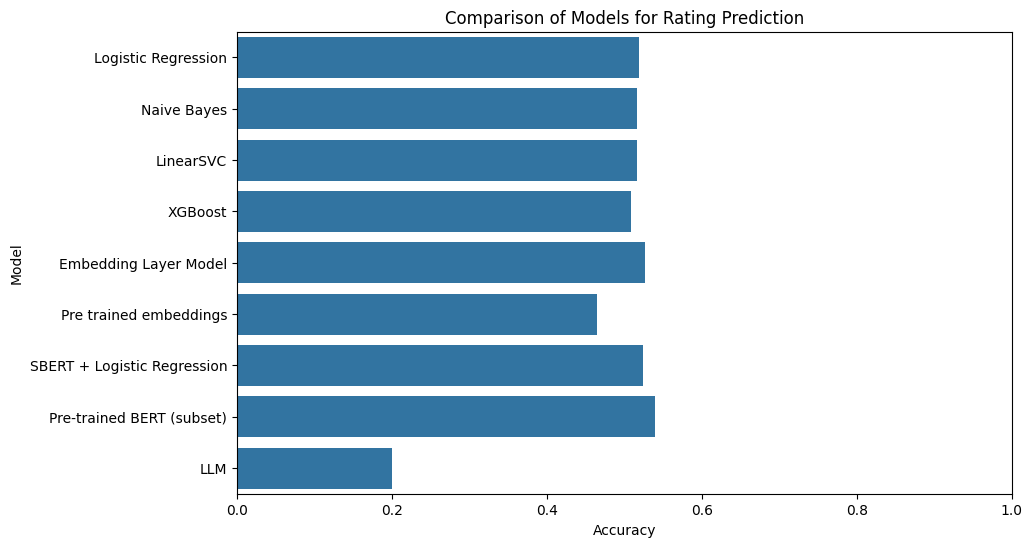

In [67]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_rating_all, x="Accuracy", y="Model")
plt.title("Comparison of Models for Rating Prediction")
plt.xlim(0, 1)
plt.show()

This first supervised task shows that predicting the exact rating of a review from 1 to 5 stars is not straightforward.

Classical TF-IDF based models already provide solid baselines which means that many useful signals are contained in the vocabulary of the reviews. More advanced approaches based on embeddings and transformers bring some improvements, especially with SBERT and BERT which better capture semantic and contextual information.

The best performance is achieved by the pre trained BERT model, suggesting that contextual representations are particularly useful for this task. However, the overall gains remain moderate which confirms that exact rating prediction is difficult because customer reviews often express nuanced and overlapping opinions.

These results motivate the next step of the analysis: sentiment classification, where the labels are broader and may therefore be easier to predict reliably.

##Part B: Sentiment Analysis

In this section, we focus on sentiment classification as a complementary supervised task.

Instead of predicting the exact rating (1–5), we group reviews into three categories:
- Negative (1–2 stars)
- Neutral (3 stars)
- Positive (4–5 stars)

This simplifies the problem and allows us to better evaluate how well models capture the overall sentiment of customer reviews.

- Create sentiment labels

In [68]:
def map_sentiment(note):
    if note <= 2:
        return "negative"
    elif note == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["note"].apply(map_sentiment)

df["sentiment"].value_counts()

,count
sentiment,
negative,10987
positive,9735
neutral,3382


- Train-test split for sentiment

In [69]:
X = df["avis_clean"]
y_sent = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(X, y_sent, test_size=0.2, random_state=42, stratify=y_sent)

### TF-IDF + Logistic regression

In [72]:
tfidf = TfidfVectorizer(max_features=1000,ngram_range=(1,3),stop_words=list(french_stopwords),min_df=5,max_df=0.9)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8041900020742585
              precision    recall  f1-score   support

    negative       0.82      0.94      0.88      2198
     neutral       0.38      0.09      0.15       676
    positive       0.82      0.90      0.85      1947

    accuracy                           0.80      4821
   macro avg       0.67      0.64      0.63      4821
weighted avg       0.76      0.80      0.77      4821



###

- Confusion matrix

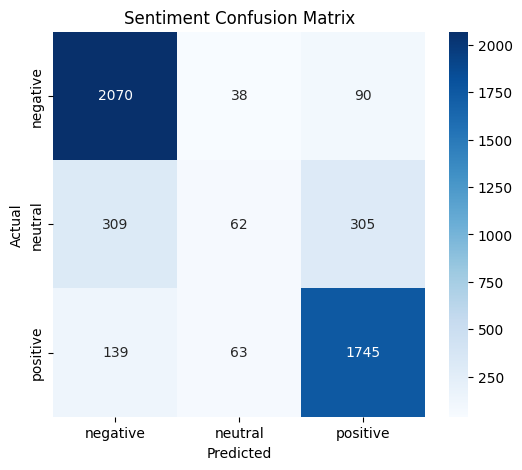

In [73]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",xticklabels=model.classes_,yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Confusion Matrix")

plt.show()

### Bert

In [75]:
from transformers import pipeline

sentiment_model = pipeline("sentiment-analysis",model="nlptown/bert-base-multilingual-uncased-sentiment")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [76]:
def bert_to_sentiment(label):
    stars = int(label[0])

    if stars <= 2:
        return "negative"
    elif stars == 3:
        return "neutral"
    else:
        return "positive"

- prediction

In [77]:
sample_X = X_test[:100]

bert_preds = sentiment_model(list(sample_X))

y_pred_bert = [bert_to_sentiment(p["label"]) for p in bert_preds]

- Evaluation

In [78]:
print("Accuracy:", accuracy_score(y_test[:100], y_pred_bert))
print(classification_report(y_test[:100], y_pred_bert))

Accuracy: 0.7
              precision    recall  f1-score   support

    negative       0.75      0.91      0.82        44
     neutral       0.36      0.19      0.25        21
    positive       0.72      0.74      0.73        35

    accuracy                           0.70       100
   macro avg       0.61      0.61      0.60       100
weighted avg       0.66      0.70      0.67       100



### Conclusion

Interestingly, the classical model (TF-IDF + Logistic Regression) outperforms the BERT-based approach on this task.

This can be explained by several factors:

- First, TF-IDF is highly effective for sentiment classification on structured datasets, as it directly captures discriminative keywords.
- Second, the BERT model used here is not fine-tuned on our specific dataset, but applied in a zero shot setting.
- Third, we evaluate BERT on a small subset due to computational constraints, which may limit its performance.

In contrast, Logistic Regression is trained directly on the dataset and can better adapt to the specific vocabulary of insurance reviews.

This result highlights that simpler models can sometimes outperform more complex models when properly trained and optimized.